In [0]:
from pyspark.sql.types import *

path = "/Volumes/project/data/dataset/meta_Appliances.jsonl"

schema = StructType([
    StructField("parent_asin", StringType(), True),
    StructField("title", StringType(), True),
    StructField("main_category", StringType(), True),
    StructField("average_rating", DoubleType(), True),
    StructField("rating_number", LongType(), True),
    StructField("price", StringType(), True),
    StructField("store", StringType(), True)
])

metadata_clean = spark.read.schema(schema).json(path)

In [0]:
metadata_clean.printSchema()

display(metadata_clean.limit(5))

root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price: string (nullable = true)
 |-- store: string (nullable = true)



parent_asin,title,main_category,average_rating,rating_number,price,store
B08Z743RRD,"ROVSUN Ice Maker Machine Countertop, Make 44lbs Ice in 24 Hours, Compact & Portable Ice Maker with Ice Basket for Home, Office, Kitchen, Bar (Silver)",Industrial & Scientific,3.7,61,null,ROVSUN
B097BQDGHJ,"HANSGO Egg Holder for Refrigerator, Deviled Eggs Dispenser Egg Storage Stackable Plastic Egg Containers Hold ups to 10 Eggs",Tools & Home Improvement,4.2,75,null,HANSGO
B00IN9AGAE,"Clothes Dryer Drum Slide, General Electric, Hotpoint, WE1M333, WE1M504",Tools & Home Improvement,3.5,18,null,GE
B0C7K98JZS,"154567702 Dishwasher Lower Wash Arm Assembly for Kenmore Electrolux Dishwasher Bottom Lower Spray Arm 5304518927, AP6810011,154567701…",Tools & Home Improvement,4.5,26,null,folosem
B07QZHQTVJ,Whirlpool W10918546 Igniter,Tools & Home Improvement,3.8,12,25.07,Whirlpool


In [0]:
from pyspark.sql.functions import col, regexp_replace

metadata_clean = (
    metadata_clean
    .withColumn(
        "price",
        regexp_replace(col("price"), "[$,]", "").cast("double")
    )
    .dropDuplicates()
    .na.drop(subset=["parent_asin", "title"])
)

In [0]:
metadata_clean = metadata_clean.drop("categories")

In [0]:
print(metadata_clean.columns)

['parent_asin', 'title', 'main_category', 'average_rating', 'rating_number', 'price', 'store']


In [0]:
from pyspark.sql.functions import sum

metadata_clean.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in metadata_clean.columns
]).show()

+-----------+-----+-------------+--------------+-------------+-----+-----+
|parent_asin|title|main_category|average_rating|rating_number|price|store|
+-----------+-----+-------------+--------------+-------------+-----+-----+
|          0|    0|         4676|             0|            0|47601|  916|
+-----------+-----+-------------+--------------+-------------+-----+-----+



In [0]:
print("Rows:", metadata_clean.count())
print("Columns:", len(metadata_clean.columns))

Rows: 94327
Columns: 7


In [0]:
metadata_clean.createOrReplaceTempView("meta_appliances")
metadata_df = metadata_clean

In [0]:
metadata_df.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price: double (nullable = true)
 |-- store: string (nullable = true)



In [0]:
metadata_df.groupBy("parent_asin") \
    .count() \
    .filter("count > 1") \
    .show(10)

+-----------+-----+
|parent_asin|count|
+-----------+-----+
+-----------+-----+



In [0]:

metadata_df.groupBy("store") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)

+------------------+-----+
|             store|count|
+------------------+-----+
|         Whirlpool| 8687|
|                GE| 4994|
|        FRIGIDAIRE| 2912|
|           SAMSUNG| 2245|
|                LG| 1876|
|UpStart Components| 1519|
|        Frigidaire| 1341|
|   Upstart Battery| 1305|
|  Supplying Demand| 1084|
|        ForeverPRO| 1024|
+------------------+-----+
only showing top 10 rows


In [0]:
from pyspark.sql.functions import regexp_replace

metadata_df = metadata_df.withColumn(
    "price_numeric",
    regexp_replace(col("price"), "[$,]", "").cast("double")
)
metadata_df.select("price_numeric").summary().show()

+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             46726|
|   mean| 86.47995398707191|
| stddev|325.31839745756383|
|    min|              0.01|
|    25%|             14.99|
|    50%|             26.99|
|    75%|              58.1|
|    max|          21095.62|
+-------+------------------+



In [0]:
for c in metadata_df.columns:
    metadata_df.selectExpr(
        f"count({c}) as {c}_non_null"
    ).show()

+--------------------+
|parent_asin_non_null|
+--------------------+
|               94327|
+--------------------+

+--------------+
|title_non_null|
+--------------+
|         94327|
+--------------+

+----------------------+
|main_category_non_null|
+----------------------+
|                 89651|
+----------------------+

+-----------------------+
|average_rating_non_null|
+-----------------------+
|                  94327|
+-----------------------+

+----------------------+
|rating_number_non_null|
+----------------------+
|                 94327|
+----------------------+

+--------------+
|price_non_null|
+--------------+
|         46726|
+--------------+

+--------------+
|store_non_null|
+--------------+
|         93411|
+--------------+

+----------------------+
|price_numeric_non_null|
+----------------------+
|                 46726|
+----------------------+



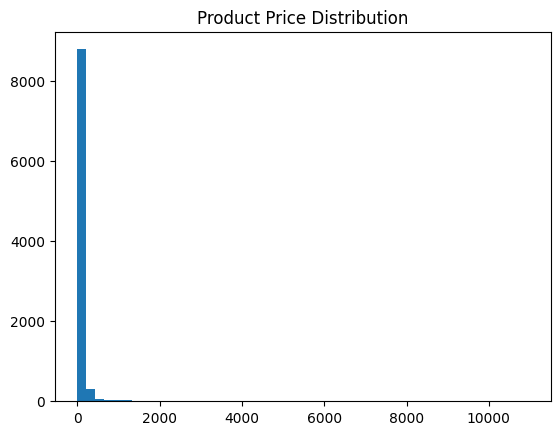

In [0]:
price_pd = metadata_df.select("price_numeric") \
    .filter("price_numeric IS NOT NULL") \
    .sample(0.2) \
    .toPandas()

import matplotlib.pyplot as plt

plt.hist(price_pd["price_numeric"], bins=50)
plt.title("Product Price Distribution")
plt.show()